<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

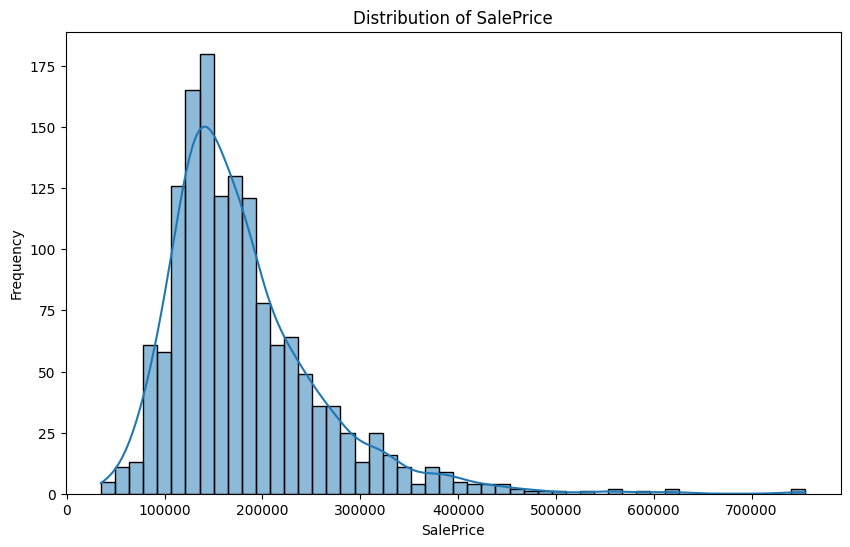

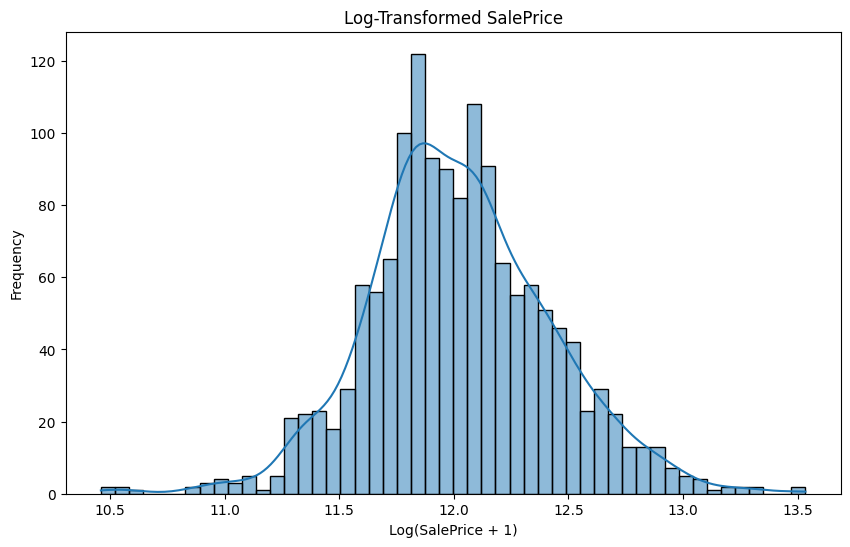

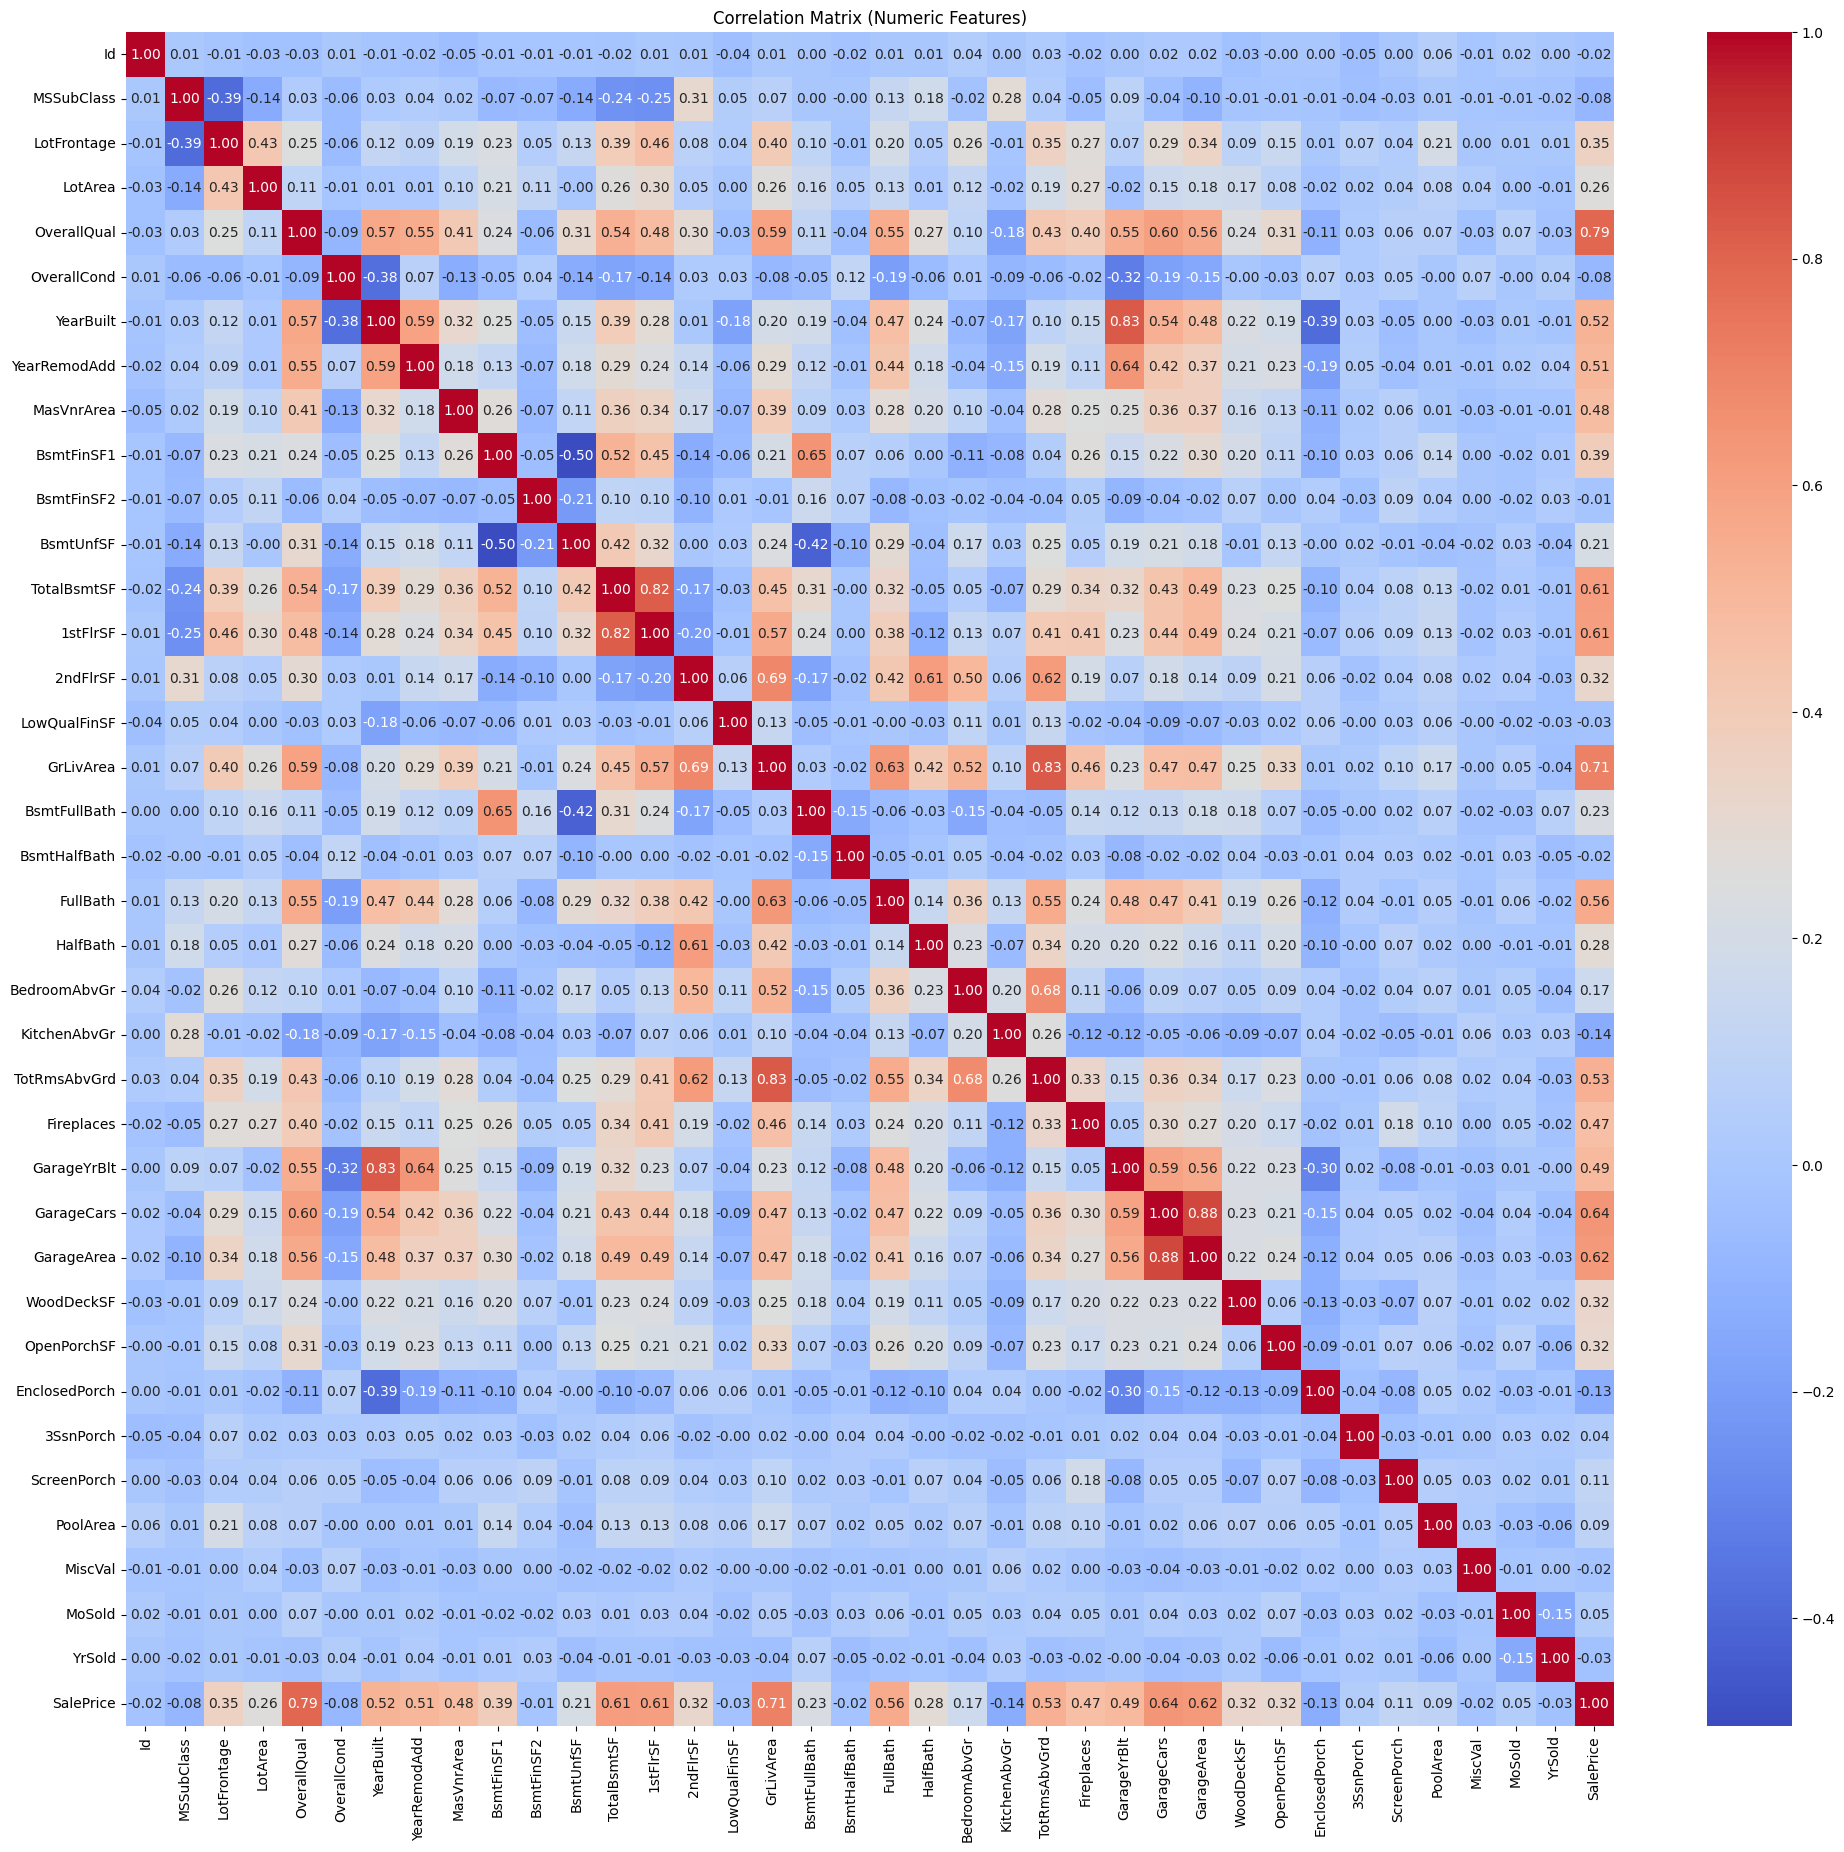

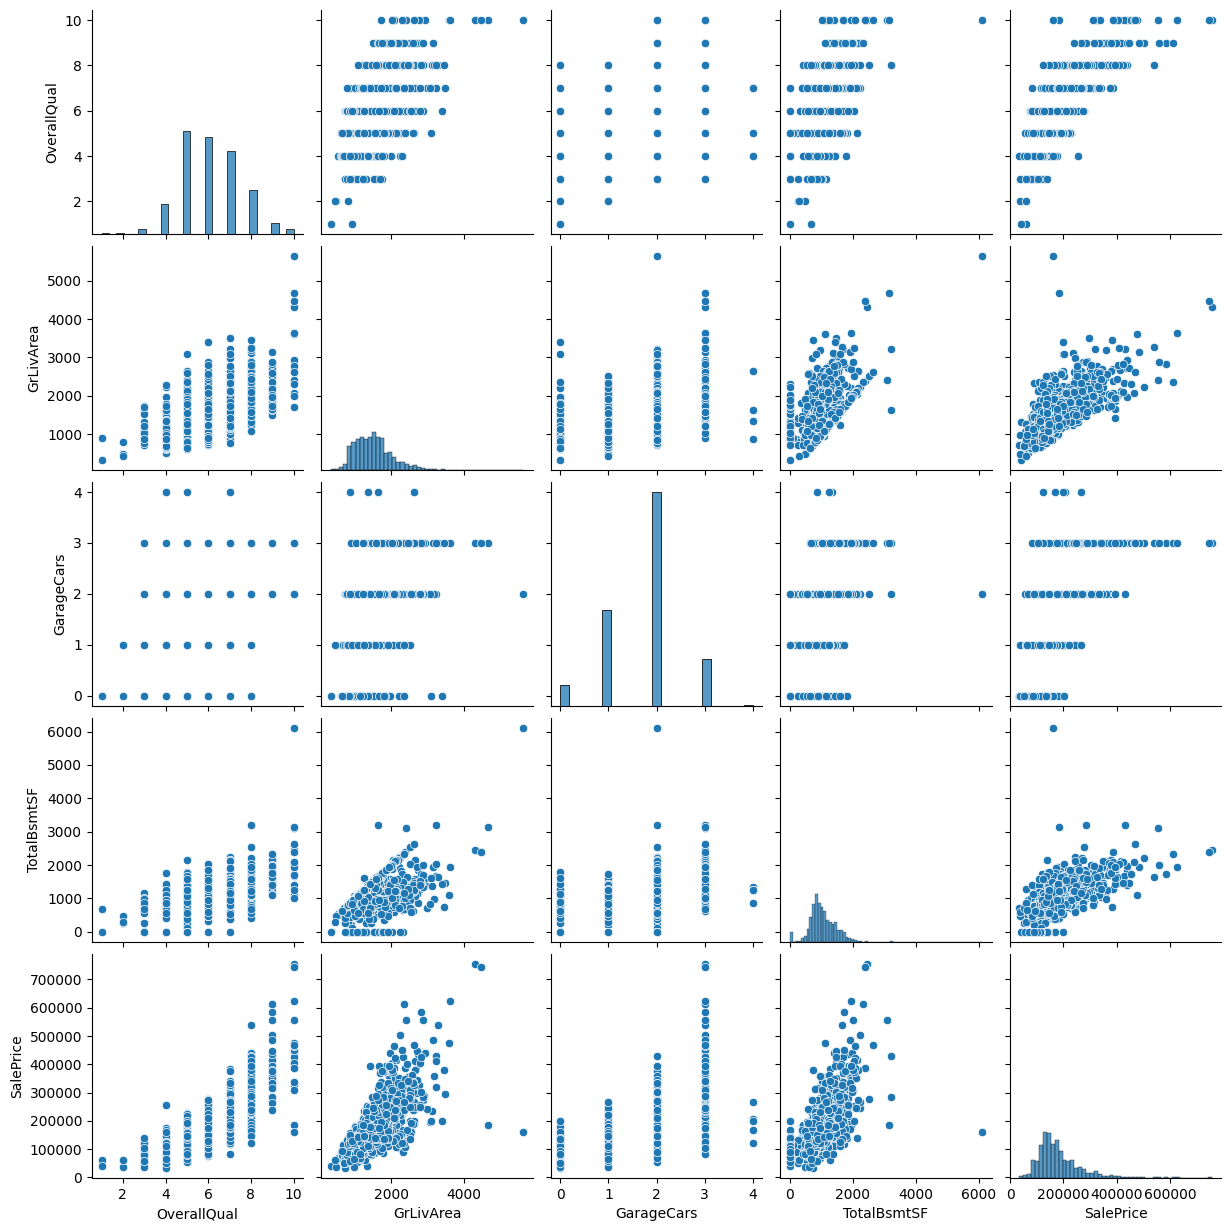

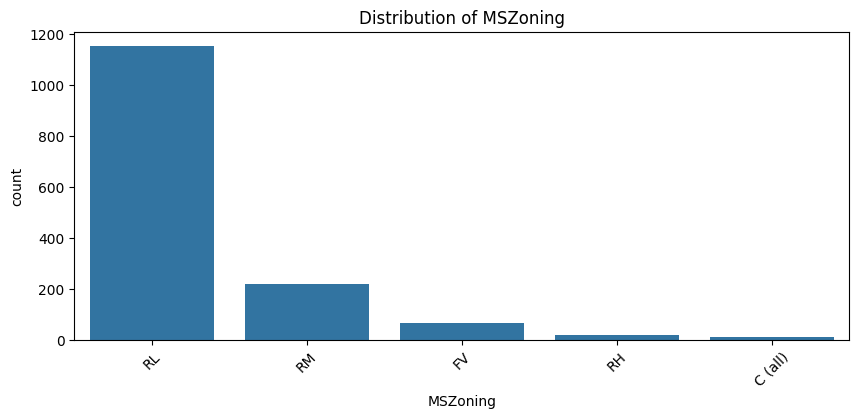

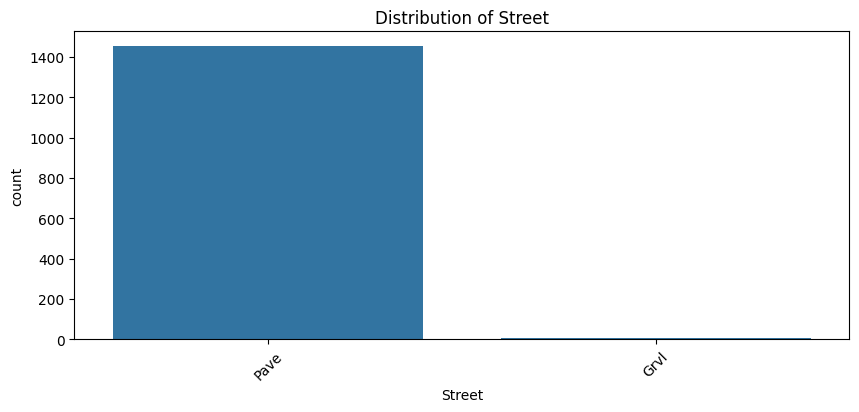

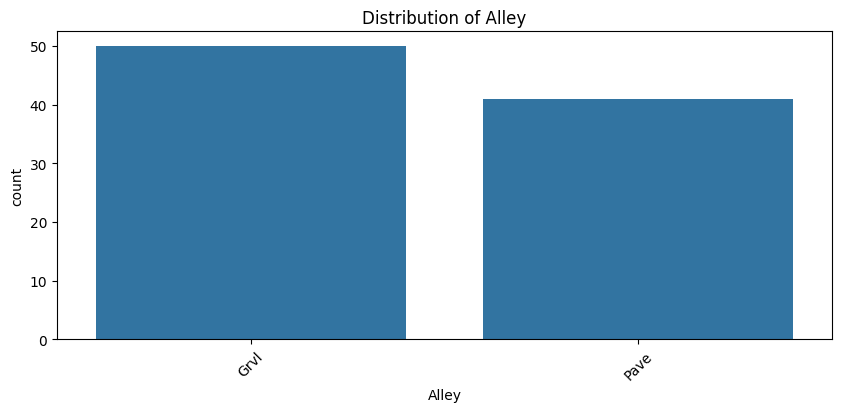

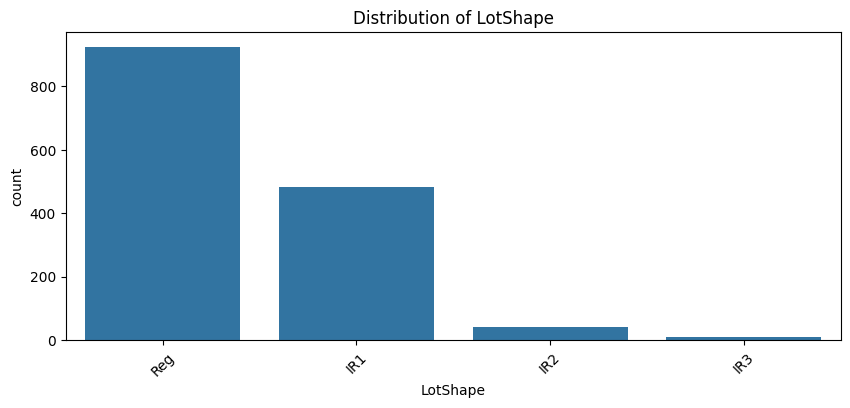

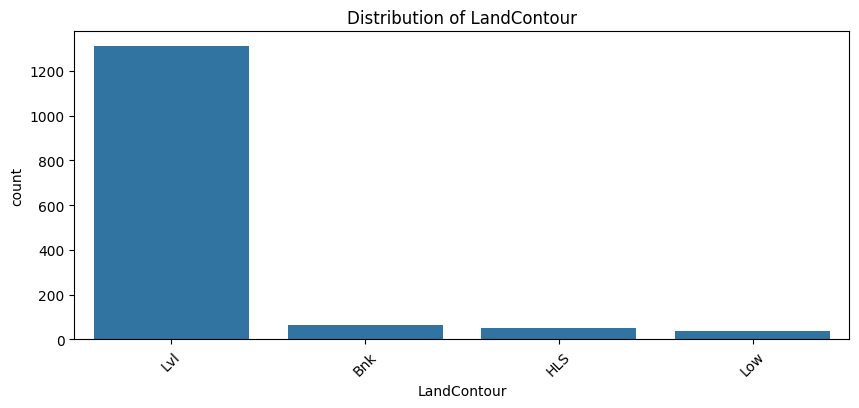

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# Target variable
y = train['SalePrice']

# -------------------------------
# 1. Basic overview
# -------------------------------
print(train.info())
print(train.describe())

# -------------------------------
# 2. Check for missing values
# -------------------------------
missing_train = train.isnull().sum()[train.isnull().sum() > 0]
missing_test = test.isnull().sum()[test.isnull().sum() > 0]

print("Missing values in train:")
print(missing_train)
print("\nMissing values in test:")
print(missing_test)

# -------------------------------
# 3. Distribution of SalePrice
# -------------------------------
plt.figure(figsize=(10,6))
sns.histplot(y, bins=50, kde=True)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

# Log-transform target (common for House Prices)
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(y), bins=50, kde=True)
plt.title("Log-Transformed SalePrice")
plt.xlabel("Log(SalePrice + 1)")
plt.ylabel("Frequency")
plt.show()

# -------------------------------
# 4. Correlation matrix for numeric features
# -------------------------------
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr_matrix = train[numeric_cols].corr()

plt.figure(figsize=(24,22))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

# -------------------------------
# 5. Pairplots for selected features
# -------------------------------
selected_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'SalePrice']
sns.pairplot(train[selected_features])
plt.show()

# -------------------------------
# 6. Categorical feature distributions
# -------------------------------
categorical_cols = train.select_dtypes(include=['object']).columns

# Example: top 5 categorical features
top_cats = categorical_cols[:5]
for col in top_cats:
    plt.figure(figsize=(10,4))
    sns.countplot(data=train, x=col, order=train[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()
